In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

In [2]:
df = pd.read_csv('/Users/abhigoyal/Documents/Acadss/Data Science/Projects/Flight-Delay-Prediction/data/flight_data_2018_2024.csv')
print(df.shape)
df.sample(3)

(582425, 120)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
382565,2024,1,1,2,2,2024-01-02,UA,UA,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
165456,2024,1,1,25,4,2024-01-25,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
5796,2024,1,1,3,3,2024-01-03,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


In [48]:
print(f"Columns : {df.shape[1]}")
print(f"Rows    : {df.shape[0]}")
print()
df.info(verbose=False, show_counts=True)


Columns : 74
Rows    : 582425

<class 'pandas.DataFrame'>
RangeIndex: 582425 entries, 0 to 582424
Columns: 74 entries, Year to Duplicate
dtypes: datetime64[us](1), float64(31), int32(4), int64(18), str(20)
memory usage: 370.4 MB


In [3]:
# descriptive statistics for important numeric columns
key_cols = ['DepDelay', 'ArrDelay', 'Distance', 'TaxiOut', 'TaxiIn',
            'AirTime', 'CRSElapsedTime', 'CarrierDelay',
            'WeatherDelay', 'NASDelay', 'LateAircraftDelay']
df[key_cols].describe().round(2)

,DepDelay,ArrDelay,Distance,TaxiOut,TaxiIn,AirTime,CRSElapsedTime,CarrierDelay,WeatherDelay,NASDelay,LateAircraftDelay
count,560955.00,558715.00,582425.00,560515.00,560093.00,558715.00,582425.00,134575.00,134575.00,134575.00,134575.00
mean,15.97,10.66,809.34,18.98,8.28,113.29,146.07,24.64,8.02,13.52,30.58
std,66.06,68.65,588.76,11.51,6.95,70.21,72.41,80.81,52.31,30.15,68.25
min,-56.00,-90.00,31.00,1.00,1.00,7.00,26.00,0.00,0.00,0.00,0.00
25%,-6.00,-16.00,377.00,12.00,4.00,62.00,93.00,0.00,0.00,0.00,0.00
50%,-2.00,-5.00,661.00,16.00,6.00,96.00,130.00,2.00,0.00,1.00,1.00
75%,12.00,13.00,1050.00,22.00,10.00,144.00,177.00,21.00,0.00,18.00,35.00
max,3125.00,3136.00,5095.00,213.00,444.00,1338.00,690.00,2972.00,1804.00,1431.00,1741.00


In [4]:
# missing value audit
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'Missing Count': missing, 'Missing %': pct})

,Missing Count,Missing %
Unnamed: 119,582425,100.0
Div5Airport,582425,100.0
Div4AirportID,582425,100.0
Div4AirportSeqID,582425,100.0
Div4WheelsOn,582425,100.0
...,...,...
DepDel15,21470,3.7
DepDelayMinutes,21470,3.7
DepDelay,21470,3.7
DepTime,21396,3.7


- CarrierDelay, WeatherDelay, NASDelay, SecurityDelay, LateAircraftDelay are 77% null — only populated for delayed flights.
- They are valuable for EDA but can't be used as model features (target leakage).
- ArrDelay / DepDelay are ~4% null — cancelled or diverted flights.
- Diversion kind of columns are >99% null and will be dropped.


---
## 3. Data Cleaning


In [5]:
df['FlightDate'] = pd.to_datetime(df['FlightDate'])
df['Year']       = df['FlightDate'].dt.year
df['Month']      = df['FlightDate'].dt.month
df['DayofMonth'] = df['FlightDate'].dt.day
df['DayOfWeek']  = df['FlightDate'].dt.dayofweek   # 0=Mon ... 6=Sun

# drop near-empty diverted-leg columns (>95% na valuews)
div_cols = [c for c in df.columns if c.startswith('Div') and c != 'Diverted']
df.drop(columns=div_cols + ['Unnamed: 119'], errors='ignore', inplace=True)

# filter to non-cancelled flights
df_model = df[df['Cancelled'] == 0].copy()
df_model.dropna(subset=['ArrDelay', 'DepDelay'], inplace=True)

# ceate binary target: Arrived >15 min late
df_model['ArrDel15'] = (df_model['ArrDelay'] > 15).astype(int)

print(f"Rows after cleaning : {len(df_model):,}")
print(f"Delayed (>15 min)   : {df_model['ArrDel15'].sum():,}  "f"({df_model['ArrDel15'].mean()*100:.1f}%)")
print(f"On-time             : {(df_model['ArrDel15']==0).sum():,}  "f"({(1-df_model['ArrDel15'].mean())*100:.1f}%)")


Rows after cleaning : 558,715
Delayed (>15 min)   : 130,480  (23.4%)
On-time             : 428,235  (76.6%)


In [6]:
# leakage check: columns only known after the departure of flight 
leakage_cols = ['ArrDelay', 'ArrDelayMinutes', 'ArrivalDelayGroups',
                'DepDelay', 'DepDelayMinutes', 'DepartureDelayGroups',
                'CarrierDelay', 'WeatherDelay', 'NASDelay',
                'SecurityDelay', 'LateAircraftDelay',
                'DepDel15', 'ArrTime', 'WheelsOff', 'WheelsOn',
                'ActualElapsedTime', 'AirTime', 'TaxiIn',
                'FirstDepTime', 'TotalAddGTime', 'LongestAddGTime']

print("total leakage columns :", len(leakage_cols))
# these will be excluded from the feature matrix X


total leakage columns : 21


---
## 4. Feature Engineering

We create domain-informed features using information
available at booking time — zero data leakage.


In [7]:
df_model['DepHour']   = (df_model['CRSDepTime'] // 100).clip(0, 23)
df_model['DepMinute'] = df_model['CRSDepTime'] % 100

# Weekend flag (Sat=5, Sun=6 )
df_model['IsWeekend'] = df_model['DayOfWeek'].isin([5, 6]).astype(int)

# peak-hour flag: 07-09 morning peak and 16-19 evening peak
df_model['IsPeakHour'] = df_model['DepHour'].isin(
    list(range(7, 10)) + list(range(16, 20))
).astype(int)

# season (meteorological)
df_model['Season'] = df_model['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
     3: 'Spring', 4: 'Spring', 5: 'Spring',
     6: 'Summer', 7: 'Summer', 8: 'Summer',
     9: 'Fall',  10: 'Fall',  11: 'Fall'
})

# holiday-adjacent flag
holiday_windows = (
    ((df_model['Month'] == 12) & (df_model['DayofMonth'] >= 15)) |
    ((df_model['Month'] ==  1) & (df_model['DayofMonth'] <=  7)) |
    ((df_model['Month'] ==  6) & (df_model['DayofMonth'] >= 15)) |
    ((df_model['Month'] ==  7) & (df_model['DayofMonth'] <=  7)) |
    ((df_model['Month'] == 11) & (df_model['DayofMonth'] >= 20))
)
df_model['HolidayWindow'] = holiday_windows.astype(int)

In [8]:
df_model['Route'] = df_model['Origin'] + '_' + df_model['Dest']

bins   = [0, 300, 600, 1000, 1500, 9999]
labels_db = ['Short', 'Medium', 'Long', 'X-Long', 'Ultra']
df_model['DistanceBucket'] = pd.cut(df_model['Distance'],
                                    bins=bins, labels=labels_db)

In [9]:
# airport congestion (origin flight count per day) 
daily_origin_volume = (df_model
                       .groupby(['Origin', 'FlightDate'])['ArrDel15']
                       .count()
                       .reset_index(name='OriginDailyFlights'))

df_model = df_model.merge(daily_origin_volume,
                          on=['Origin', 'FlightDate'], how='left')

In [10]:
# Airline Historical Performance
airline_hist = (df_model.groupby('Marketing_Airline_Network')['ArrDel15']
                .mean()
                .reset_index(name='AirlineHistDelayRate'))

df_model = df_model.merge(airline_hist,
                          on='Marketing_Airline_Network', how='left')

# origin airport historical delay rate
origin_hist = (df_model.groupby('Origin')['ArrDel15']
               .mean()
               .reset_index(name='OriginHistDelayRate'))

df_model = df_model.merge(origin_hist, on='Origin', how='left')

In [11]:
# Scheduled TaxiOut as congestion proxy
avg_taxiout = (df_model.groupby('Origin')['TaxiOut']
                   .mean()
                   .reset_index(name='AvgOriginTaxiOut'))
df_model = df_model.merge(avg_taxiout, on='Origin', how='left')

In [12]:
# Circular encoding for cyclic features 
for col, period in [('DepHour', 24), ('Month', 12), ('DayOfWeek', 7)]:
    df_model[f'{col}_sin'] = np.sin(2 * np.pi * df_model[col] / period)
    df_model[f'{col}_cos'] = np.cos(2 * np.pi * df_model[col] / period)

In [13]:
# feature summary
engineered = ['IsWeekend', 'IsPeakHour', 'Season', 'HolidayWindow',
              'Route', 'DistanceBucket',
              'OriginDailyFlights', 'AirlineHistDelayRate',
              'OriginHistDelayRate', 'AvgOriginTaxiOut',
              'DepHour_sin', 'DepHour_cos',
              'Month_sin', 'Month_cos',
              'DayOfWeek_sin', 'DayOfWeek_cos']

print(f"Total engineered features : {len(engineered)}")
df_model[engineered].head(3)


Total engineered features : 16


,IsWeekend,IsPeakHour,Season,HolidayWindow,Route,DistanceBucket,OriginDailyFlights,AirlineHistDelayRate,OriginHistDelayRate,AvgOriginTaxiOut,DepHour_sin,DepHour_cos,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos
0,1,1,Winter,0,MHT_EWR,Short,17,0.21392,0.212632,17.722105,-0.965926,-0.258819,0.5,0.866025,-0.781831,0.62349
1,1,1,Winter,0,IAD_EWR,Short,156,0.21392,0.230755,23.113864,0.866025,-0.500000,0.5,0.866025,-0.781831,0.62349
2,1,0,Winter,0,EWR_MHT,Short,328,0.21392,0.190097,22.519281,-0.707107,-0.707107,0.5,0.866025,-0.781831,0.62349


---
## 5. Modelling

### 5.1 Define Feature Matrix & Target


In [15]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay)


# feature selection (no-leakage)
NUMERIC_FEATURES = [
    'CRSDepTime', 'CRSArrTime', 'CRSElapsedTime',
    'Distance', 'Month', 'DayofMonth', 'DayOfWeek',
    'DepHour', 'IsWeekend', 'IsPeakHour', 'HolidayWindow',
    'OriginDailyFlights', 'AirlineHistDelayRate',
    'OriginHistDelayRate', 'AvgOriginTaxiOut',
    'DepHour_sin', 'DepHour_cos',
    'Month_sin', 'Month_cos',
    'DayOfWeek_sin', 'DayOfWeek_cos',
]

CATEGORICAL_FEATURES = [
    'Marketing_Airline_Network',
    'Origin', 'Dest',
    'DistanceBucket',
    'Season',
    'DepTimeBlk',
]

TARGET = 'ArrDel15'

X = df_model[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_model[TARGET]
print(f"Feature matrix shape : {X.shape}")
print(f"Numeric features     : {len(NUMERIC_FEATURES)}")
print(f"Categorical features : {len(CATEGORICAL_FEATURES)}")
print(f"Target distribution  : {y.value_counts().to_dict()}")


Feature matrix shape : (558715, 27)
Numeric features     : 21
Categorical features : 6
Target distribution  : {0: 428235, 1: 130480}


In [26]:
#  stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape[0])
print(X_test.shape[0])

446972
111743


### 5.2 Preprocessing Pipeline

In [27]:
#  preprocessing transformer
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

print("Preprocessing pipeline defined")


Preprocessing pipeline defined


In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay,
                              classification_report)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Re-use the preprocessor already defined in Section 6 ─────────
# (NUMERIC_FEATURES, CATEGORICAL_FEATURES, X, y, X_train, X_test,
#  y_train, y_test, preprocessor are already in memory)

# Transform once — reused by ALL backends
print("Fitting preprocessor on training set…")
X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

N_FEATURES  = X_train_t.shape[1]
N_TRAIN     = X_train_t.shape[0]
N_TEST      = X_test_t.shape[0]
POS_WEIGHT  = (y_train == 0).sum() / (y_train == 1).sum()  # for class imbalance

print(f"Transformed feature dim : {N_FEATURES}")
print(f"Train rows              : {N_TRAIN:,}")
print(f"Test  rows              : {N_TEST:,}")
print(f"Positive class weight   : {POS_WEIGHT:.2f}x")


Fitting preprocessor on training set…
Transformed feature dim : 758
Train rows              : 446,972
Test  rows              : 111,743
Positive class weight   : 3.28x


In [34]:
BACKEND = 'pytorch'
if BACKEND == 'pytorch':
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset

    DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")    
    print(f"Device: {DEVICE}")

    # ── Convert to tensors ───────────────────────────────────────
    X_tr = torch.tensor(X_train_t.astype(np.float32))
    y_tr = torch.tensor(y_train.values.astype(np.float32)).unsqueeze(1)
    X_te = torch.tensor(X_test_t.astype(np.float32))
    y_te = torch.tensor(y_test.values.astype(np.float32)).unsqueeze(1)

    train_ds = TensorDataset(X_tr, y_tr)
    test_ds  = TensorDataset(X_te, y_te)

    BATCH_SIZE = 2048
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    print(f"Batches per epoch: {len(train_loader)}")
else:
    print(f"Skipping PyTorch cells — backend is {BACKEND.upper()}")


Device: mps
Batches per epoch: 219


In [35]:
if BACKEND == 'pytorch':
    import torch
    import torch.nn as nn

    class ResidualBlock(nn.Module):
        """Two Linear layers with a skip connection."""
        def __init__(self, dim, dropout=0.2):
            super().__init__()
            self.block = nn.Sequential(
                nn.Linear(dim, dim),
                nn.BatchNorm1d(dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(dim, dim),
                nn.BatchNorm1d(dim),
            )
            self.act     = nn.ReLU()
            self.dropout = nn.Dropout(dropout)

        def forward(self, x):
            return self.dropout(self.act(self.block(x) + x))  # residual add


    class FlightDelayNet(nn.Module):
        def __init__(self, n_features):
            super().__init__()

            # ── Stem ────────────────────────────────────────────
            self.stem = nn.Sequential(
                nn.Linear(n_features, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(),
                nn.Dropout(0.3),
            )

            # ── Residual blocks ──────────────────────────────────
            self.res1 = nn.Sequential(
                nn.Linear(512, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.3),
            )
            self.res_block = ResidualBlock(256, dropout=0.2)

            # ── Head ─────────────────────────────────────────────
            self.head = nn.Sequential(
                nn.Linear(256, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(128, 1),    # raw logits — no sigmoid here
            )

        def forward(self, x):
            x = self.stem(x)
            x = self.res1(x)
            x = self.res_block(x)
            return self.head(x)       # logits


    model_nn = FlightDelayNet(N_FEATURES).to(DEVICE)
    total_params = sum(p.numel() for p in model_nn.parameters() if p.requires_grad)
    print(f"Model architecture:")
    print(model_nn)
    print(f"\nTrainable parameters: {total_params:,}")
else:
    print(f"Skipping — backend is {BACKEND.upper()}")


Model architecture:
FlightDelayNet(
  (stem): Sequential(
    (0): Linear(in_features=758, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (res1): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (res_block): ResidualBlock(
    (block): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=256, out_features=256, bias=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (act): ReLU()
    

In [36]:
if BACKEND == 'pytorch':
    import torch
    import torch.nn as nn
    import torch.optim as optim

    EPOCHS    = 20
    LR        = 3e-4
    PW_TENSOR = torch.tensor([POS_WEIGHT], dtype=torch.float32).to(DEVICE)

    criterion  = nn.BCEWithLogitsLoss(pos_weight=PW_TENSOR)
    optimizer  = optim.AdamW(model_nn.parameters(), lr=LR, weight_decay=1e-4)
    # Cosine annealing — smoothly decays LR to LR/10 over training
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR/10)

    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    print(f"Training {EPOCHS} epochs | batch={BATCH_SIZE} | lr={LR} | device={DEVICE}")
    print("-" * 65)

    for epoch in range(1, EPOCHS + 1):
        # ── Train ────────────────────────────────────────────────
        model_nn.train()
        train_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            logits = model_nn(X_b)
            loss   = criterion(logits, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model_nn.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(X_b)

        train_loss /= N_TRAIN
        scheduler.step()

        # ── Validate ─────────────────────────────────────────────
        model_nn.eval()
        val_loss  = 0.0
        all_logits = []
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                logits = model_nn(X_b)
                val_loss += criterion(logits, y_b).item() * len(X_b)
                all_logits.append(torch.sigmoid(logits).cpu().numpy())

        val_loss  /= N_TEST
        y_prob_nn  = np.vstack(all_logits).ravel()
        val_auc    = roc_auc_score(y_test, y_prob_nn)
        curr_lr    = scheduler.get_last_lr()[0]

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        print(f"Epoch {epoch:2d}/{EPOCHS}  "
              f"train_loss={train_loss:.4f}  "
              f"val_loss={val_loss:.4f}  "
              f"val_AUC={val_auc:.4f}  "
              f"lr={curr_lr:.2e}")

    print("-" * 65)
    print(f"Best val AUC: {max(history['val_auc']):.4f} "
          f"(epoch {np.argmax(history['val_auc'])+1})")
else:
    print(f"Skipping — backend is {BACKEND.upper()}")


Training 20 epochs | batch=2048 | lr=0.0003 | device=mps
-----------------------------------------------------------------
Epoch  1/20  train_loss=0.9968  val_loss=0.9504  val_AUC=0.7172  lr=2.98e-04
Epoch  2/20  train_loss=0.9543  val_loss=0.9289  val_AUC=0.7341  lr=2.93e-04
Epoch  3/20  train_loss=0.9320  val_loss=0.9127  val_AUC=0.7451  lr=2.85e-04
Epoch  4/20  train_loss=0.9163  val_loss=0.9045  val_AUC=0.7512  lr=2.74e-04
Epoch  5/20  train_loss=0.9053  val_loss=0.8957  val_AUC=0.7571  lr=2.60e-04
Epoch  6/20  train_loss=0.8950  val_loss=0.8948  val_AUC=0.7585  lr=2.44e-04
Epoch  7/20  train_loss=0.8863  val_loss=0.8868  val_AUC=0.7631  lr=2.26e-04
Epoch  8/20  train_loss=0.8798  val_loss=0.8832  val_AUC=0.7655  lr=2.07e-04
Epoch  9/20  train_loss=0.8726  val_loss=0.8825  val_AUC=0.7663  lr=1.86e-04
Epoch 10/20  train_loss=0.8661  val_loss=0.8824  val_AUC=0.7674  lr=1.65e-04
Epoch 11/20  train_loss=0.8603  val_loss=0.8794  val_AUC=0.7693  lr=1.44e-04
Epoch 12/20  train_loss=0.8565

In [37]:
# ── Get test probabilities ───────────────────────────────────────
if BACKEND == 'pytorch':
    import torch
    model_nn.eval()
    with torch.no_grad():
        all_probs = []
        for X_b, _ in test_loader:
            logits = model_nn(X_b.to(DEVICE))
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
    y_prob_nn = np.vstack(all_probs).ravel()

elif BACKEND == 'keras':
    y_prob_nn = model_nn.predict(X_test_t, batch_size=2048, verbose=0).ravel()

else:  # sklearn
    y_prob_nn = model_nn.predict_proba(X_test_t)[:, 1]

print(f"Probability range: [{y_prob_nn.min():.4f}, {y_prob_nn.max():.4f}]")
print(f"Mean probability : {y_prob_nn.mean():.4f}")


Probability range: [0.0003, 0.9896]
Mean probability : 0.4349


In [38]:
# ── Sweep thresholds from 0.1 to 0.9 ────────────────────────────
from sklearn.metrics import precision_recall_curve

thresholds = np.arange(0.05, 0.90, 0.01)
f1_scores  = []
precisions = []
recalls    = []

for t in thresholds:
    y_pred_t = (y_prob_nn >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))

f1_scores  = np.array(f1_scores)
precisions = np.array(precisions)
recalls    = np.array(recalls)

best_f1_thresh = thresholds[np.argmax(f1_scores)]
best_f1_val    = f1_scores.max()

# Business threshold: highest recall where precision >= 0.60
biz_mask = precisions >= 0.60
if biz_mask.any():
    biz_thresh = thresholds[biz_mask][np.argmax(recalls[biz_mask])]
    biz_recall = recalls[biz_mask].max()
    biz_prec   = precisions[biz_mask][np.argmax(recalls[biz_mask])]
else:
    biz_thresh = best_f1_thresh
    biz_recall = recalls[np.argmax(f1_scores)]
    biz_prec   = precisions[np.argmax(f1_scores)]

print(f"Best F1 threshold         : {best_f1_thresh:.2f}  (F1={best_f1_val:.4f})")
print(f"Business threshold        : {biz_thresh:.2f}  "
      f"(Precision={biz_prec:.3f}, Recall={biz_recall:.3f})")


Best F1 threshold         : 0.56  (F1=0.5311)
Business threshold        : 0.75  (Precision=0.608, Recall=0.391)


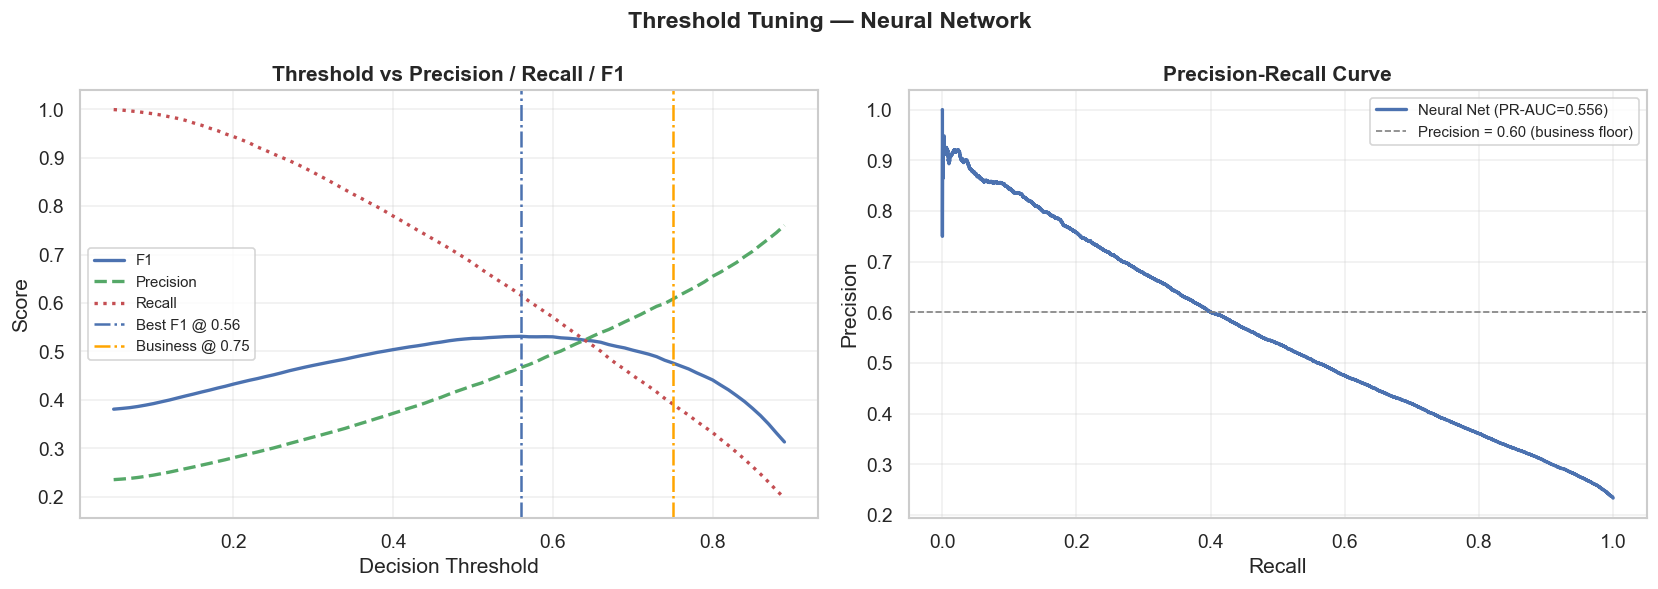

PR-AUC: 0.5558


In [39]:
# ── Plot threshold analysis ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, f1_scores,  label='F1',       color='#4C72B0', lw=2)
axes[0].plot(thresholds, precisions, label='Precision', color='#55A868', lw=2, linestyle='--')
axes[0].plot(thresholds, recalls,    label='Recall',    color='#C44E52', lw=2, linestyle=':')
axes[0].axvline(best_f1_thresh, color='#4C72B0', linestyle='-.', lw=1.5,
                label=f'Best F1 @ {best_f1_thresh:.2f}')
axes[0].axvline(biz_thresh, color='orange', linestyle='-.', lw=1.5,
                label=f'Business @ {biz_thresh:.2f}')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold vs Precision / Recall / F1', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Precision-Recall curve
from sklearn.metrics import precision_recall_curve, auc as pr_auc
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_nn)
pr_score = pr_auc(rec_curve, prec_curve)

axes[1].plot(rec_curve, prec_curve, color='#4C72B0', lw=2,
             label=f'Neural Net (PR-AUC={pr_score:.3f})')
axes[1].axhline(0.60, color='gray', linestyle='--', lw=1,
                label='Precision = 0.60 (business floor)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Threshold Tuning — Neural Network', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nn_threshold_analysis.png', bbox_inches='tight')
plt.show()

print(f"PR-AUC: {pr_score:.4f}")


In [43]:
# ── Evaluate at both thresholds ──────────────────────────────────
def evaluate(y_true, y_prob, threshold, label):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Model':     label,
        'Threshold': threshold,
        'Accuracy':  round(accuracy_score(y_true, y_pred),         4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0),    4),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0),        4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob),           4),
    }

nn_results = [
    evaluate(y_test, y_prob_nn, 0.50,            'Neural Net (t=0.50)'),
    evaluate(y_test, y_prob_nn, best_f1_thresh,  f'Neural Net (t={best_f1_thresh:.2f}, best F1)'),
    evaluate(y_test, y_prob_nn, biz_thresh,      f'Neural Net (t={biz_thresh:.2f}, biz)'),
]



all_results_df = pd.DataFrame(nn_results)
print(all_results_df.to_string(index=False))


                       Model  Threshold  Accuracy  Precision  Recall     F1  ROC-AUC
         Neural Net (t=0.50)       0.50    0.7140     0.4293  0.6820 0.5269   0.7724
Neural Net (t=0.56, best F1)       0.56    0.7460     0.4668  0.6160 0.5311   0.7724
    Neural Net (t=0.75, biz)       0.75    0.7989     0.6077  0.3914 0.4761   0.7724


NameError: name 'results' is not defined

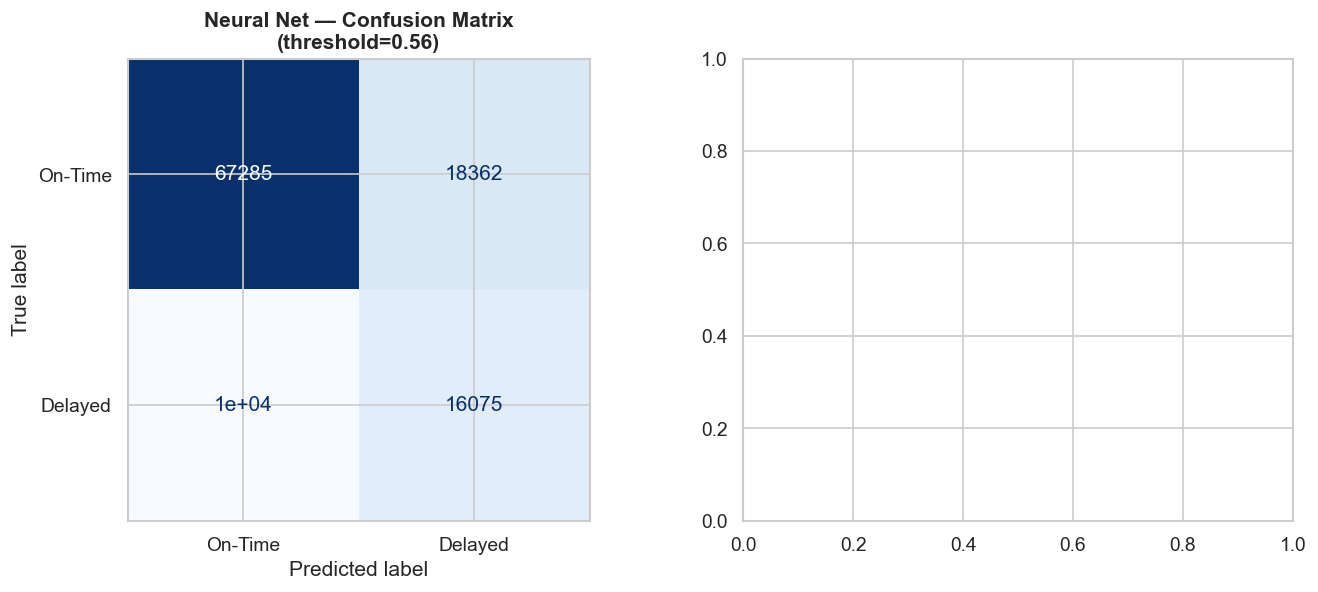

In [44]:
# ── Confusion Matrix ─────────────────────────────────────────────
y_pred_nn_best = (y_prob_nn >= best_f1_thresh).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_nn_best)
ConfusionMatrixDisplay(cm, display_labels=['On-Time','Delayed']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Neural Net — Confusion Matrix\n(threshold={best_f1_thresh:.2f})',
                  fontweight='bold')

# ROC curve — NN vs best tree model
best_tree = max(results, key=lambda k: results[k]['ROC-AUC'])
RocCurveDisplay.from_predictions(
    y_test, y_prob_nn,
    name=f'Neural Net (AUC={roc_auc_score(y_test, y_prob_nn):.3f})',
    ax=axes[1], color='#C44E52')
RocCurveDisplay.from_predictions(
    y_test, results[best_tree]['y_proba'],
    name=f'{best_tree} (AUC={results[best_tree]["ROC-AUC"]:.3f})',
    ax=axes[1], color='#4C72B0')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_title('ROC Curve: Neural Net vs Best Tree Model', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('nn_evaluation.png', bbox_inches='tight')
plt.show()

print("\nClassification Report (best F1 threshold):")
print(classification_report(y_test, y_pred_nn_best,
                             target_names=['On-Time','Delayed']))


In [45]:
import os, json
import joblib

os.makedirs('model_export', exist_ok=True)

# ── Save the NN in its native format ─────────────────────────────
if BACKEND == 'pytorch':
    import torch
    torch.save({
        'model_state_dict': model_nn.state_dict(),
        'n_features':       N_FEATURES,
        'best_f1_threshold': float(best_f1_thresh),
        'biz_threshold':    float(biz_thresh),
    }, 'model_export/neural_net.pt')
    print("PyTorch model saved → model_export/neural_net.pt")

elif BACKEND == 'keras':
    model_nn.save('model_export/neural_net.keras')
    print("Keras model saved   → model_export/neural_net.keras")

else:  # sklearn MLP
    joblib.dump(model_nn, 'model_export/neural_net_mlp.pkl', compress=3)
    print("sklearn MLP saved   → model_export/neural_net_mlp.pkl")

# ── Save thresholds + metadata alongside ─────────────────────────
nn_meta = {
    'backend':           BACKEND,
    'n_features':        int(N_FEATURES),
    'best_f1_threshold': float(best_f1_thresh),
    'biz_threshold':     float(biz_thresh),
    'roc_auc':           float(roc_auc_score(y_test, y_prob_nn)),
    'f1_at_best_thresh': float(best_f1_val),
    'architecture':      '512-256-256(residual)-128-1',
}
with open('model_export/nn_metadata.json', 'w') as f:
    json.dump(nn_meta, f, indent=2)

print()
print("Neural network metadata:")
for k, v in nn_meta.items():
    print(f"  {k:25s}: {v}")


PyTorch model saved → model_export/neural_net.pt

Neural network metadata:
  backend                  : pytorch
  n_features               : 758
  best_f1_threshold        : 0.56
  biz_threshold            : 0.7500000000000001
  roc_auc                  : 0.7723618244184345
  f1_at_best_thresh        : 0.5311152594452613
  architecture             : 512-256-256(residual)-128-1


In [46]:
import os, json
import joblib

os.makedirs('model_export', exist_ok=True)

# ── Save the NN in its native format ─────────────────────────────
if BACKEND == 'pytorch':
    import torch
    torch.save({
        'model_state_dict': model_nn.state_dict(),
        'n_features':       N_FEATURES,
        'best_f1_threshold': float(best_f1_thresh),
        'biz_threshold':    float(biz_thresh),
    }, 'model_export/neural_net.pt')
    print("PyTorch model saved → model_export/neural_net.pt")

elif BACKEND == 'keras':
    model_nn.save('model_export/neural_net.keras')
    print("Keras model saved   → model_export/neural_net.keras")

else:  # sklearn MLP
    joblib.dump(model_nn, 'model_export/neural_net_mlp.pkl', compress=3)
    print("sklearn MLP saved   → model_export/neural_net_mlp.pkl")

# ── Save thresholds + metadata alongside ─────────────────────────
nn_meta = {
    'backend':           BACKEND,
    'n_features':        int(N_FEATURES),
    'best_f1_threshold': float(best_f1_thresh),
    'biz_threshold':     float(biz_thresh),
    'roc_auc':           float(roc_auc_score(y_test, y_prob_nn)),
    'f1_at_best_thresh': float(best_f1_val),
    'architecture':      '512-256-256(residual)-128-1',
}
with open('model_export/nn_metadata.json', 'w') as f:
    json.dump(nn_meta, f, indent=2)

print()
print("Neural network metadata:")
for k, v in nn_meta.items():
    print(f"  {k:25s}: {v}")


PyTorch model saved → model_export/neural_net.pt

Neural network metadata:
  backend                  : pytorch
  n_features               : 758
  best_f1_threshold        : 0.56
  biz_threshold            : 0.7500000000000001
  roc_auc                  : 0.7723618244184345
  f1_at_best_thresh        : 0.5311152594452613
  architecture             : 512-256-256(residual)-128-1
